In [3]:
# importing the libraries i need
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset
df = pd.read_csv('dataset_phishing.csv')

# look at the data
print("first 5 rows:")
print(df.head())

# how many rows and columns
print("size of dataset:")
print(df.shape)

# count phishing vs legitimate
print("phishing vs legitimate count:")
print(df['status'].value_counts())

# check for missing values
print("missing values:")
print(df.isnull().sum().sum())

first 5 rows:
                                                 url  length_url  \
0              http://www.crestonwood.com/router.php          37   
1  http://shadetreetechnology.com/V4/validation/a...          77   
2  https://support-appleld.com.secureupdate.duila...         126   
3                                 http://rgipt.ac.in          18   
4  http://www.iracing.com/tracks/gateway-motorspo...          55   

   length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  ...  \
0               19   0        3           0      0      0       0      0  ...   
1               23   1        1           0      0      0       0      0  ...   
2               50   1        4           1      0      1       2      0  ...   
3               11   0        2           0      0      0       0      0  ...   
4               15   0        2           2      0      0       0      0  ...   

   domain_in_title  domain_with_copyright  whois_registered_domain  \
0                0  

training size: 9144
testing size: 2286
accuracy: 96.76 %
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1128
           1       0.98      0.96      0.97      1158

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97      0.97      0.97      2286



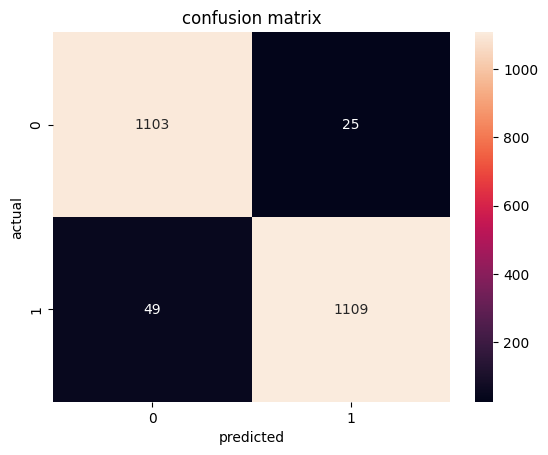

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# remove the url column because its text not numbers
X = df.drop(columns=['url', 'status'])
y = df['status']

# convert text labels to numbers
y = y.map({'legitimate': 0, 'phishing': 1})

# split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("training size:", len(X_train))
print("testing size:", len(X_test))

# build the model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# test the model
y_pred = model.predict(X_test)

# print accuracy
acc = accuracy_score(y_test, y_pred)
print("accuracy:", round(acc * 100, 2), "%")

# detailed results
print(classification_report(y_test, y_pred))

# draw confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('confusion matrix')
plt.ylabel('actual')
plt.xlabel('predicted')
plt.savefig('confusion_matrix.png')
plt.show()

Random Forest accuracy: 97.07 %
Decision Tree accuracy: 93.92 %


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression accuracy: 82.72 %
KNN accuracy: 83.6 %
Naive Bayes accuracy: 76.29 %


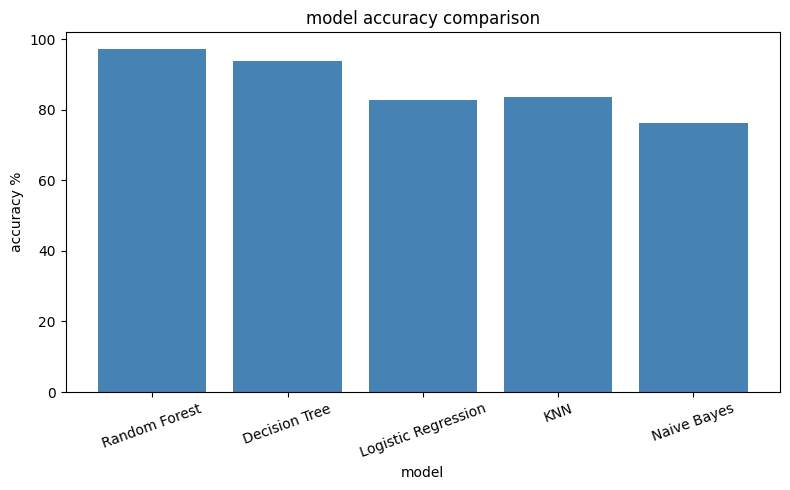

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# list of models i want to try
names = ['Random Forest', 'Decision Tree',
         'Logistic Regression', 'KNN', 'Naive Bayes']

models = [
    RandomForestClassifier(n_estimators=100),
    DecisionTreeClassifier(),
    LogisticRegression(max_iter=1000),
    KNeighborsClassifier(),
    GaussianNB()
]

# train each model and save accuracy
results = []

for i in range(len(models)):
    models[i].fit(X_train, y_train)
    pred = models[i].predict(X_test)
    acc = accuracy_score(y_test, pred) * 100
    results.append(round(acc, 2))
    print(names[i], "accuracy:", round(acc, 2), "%")

# draw bar chart
plt.figure(figsize=(8, 5))
plt.bar(names, results, color='steelblue')
plt.title('model accuracy comparison')
plt.ylabel('accuracy %')
plt.xlabel('model')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

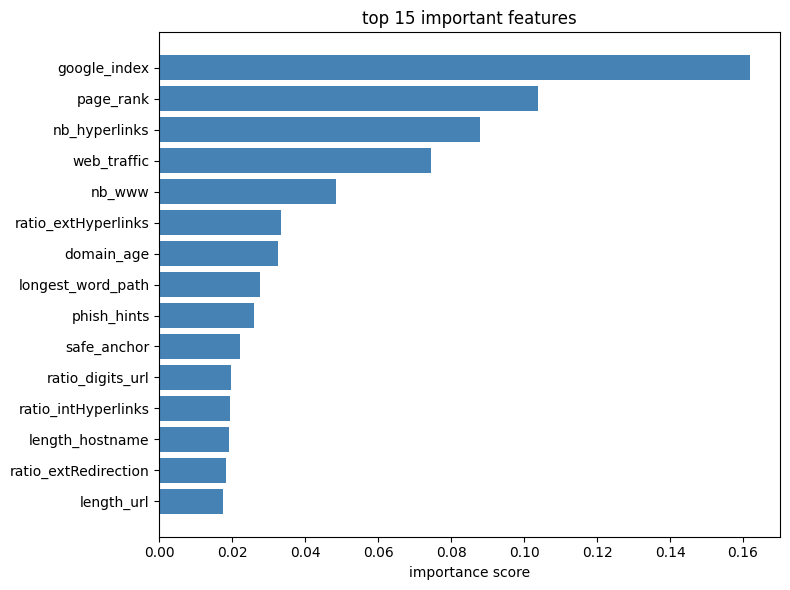

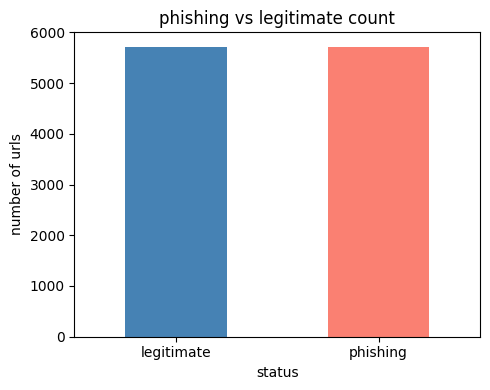

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# chart 1: feature importance
# which columns matter most for detecting phishing

rf_model = models[0]
importances = rf_model.feature_importances_
feature_names = X.columns

# get top 15 most important features
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(8, 6))
plt.barh(range(15), importances[indices], color='steelblue')
plt.yticks(range(15), feature_names[indices])
plt.title('top 15 important features')
plt.xlabel('importance score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# chart 2: class distribution
plt.figure(figsize=(5, 4))
df['status'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('phishing vs legitimate count')
plt.ylabel('number of urls')
plt.xlabel('status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

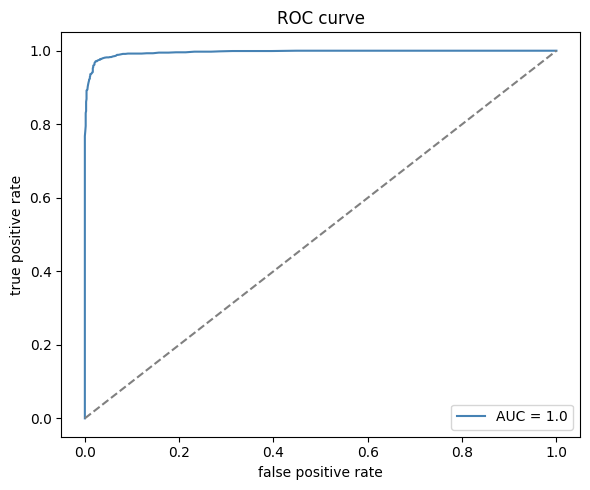

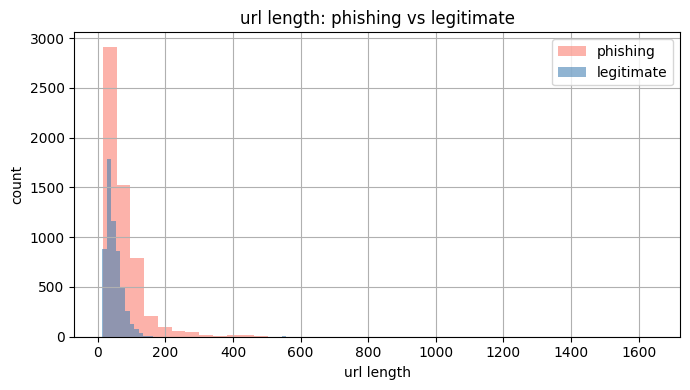

In [7]:
from sklearn.metrics import roc_curve, auc

# chart 3: ROC curve
rf_model = models[0]
y_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', label='AUC = ' + str(round(roc_auc, 2)))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC curve')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

# chart 4: url length distribution
plt.figure(figsize=(7, 4))
df[df['status'] == 'phishing']['length_url'].hist(
    bins=40, alpha=0.6, color='salmon', label='phishing')
df[df['status'] == 'legitimate']['length_url'].hist(
    bins=40, alpha=0.6, color='steelblue', label='legitimate')
plt.title('url length: phishing vs legitimate')
plt.xlabel('url length')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.savefig('url_length_distribution.png')
plt.show()

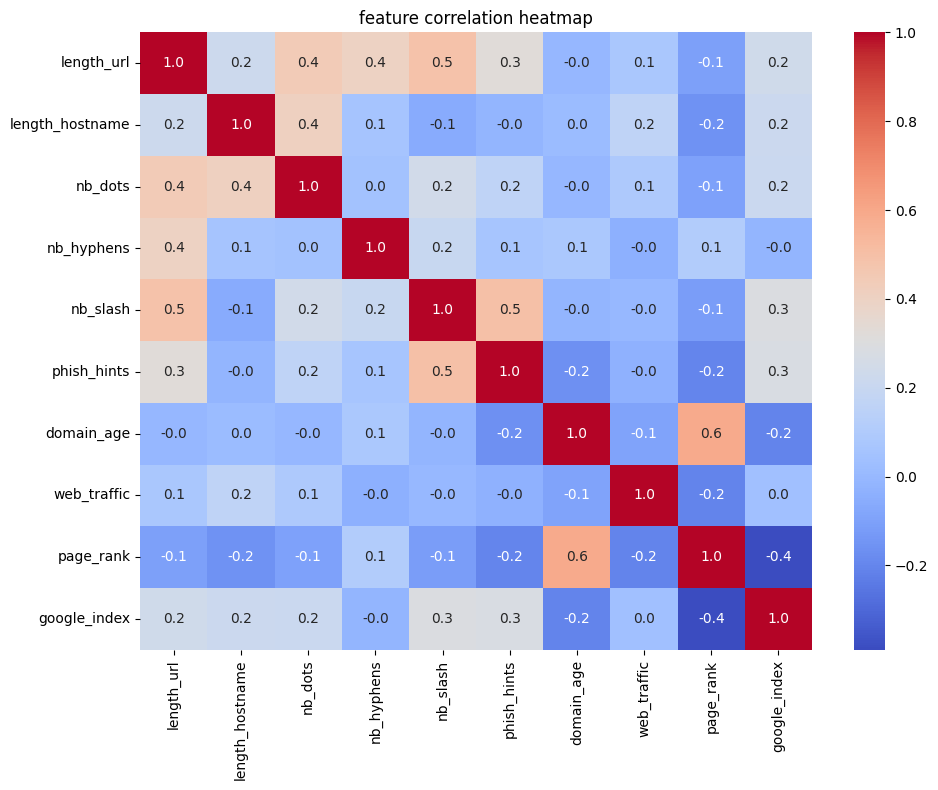

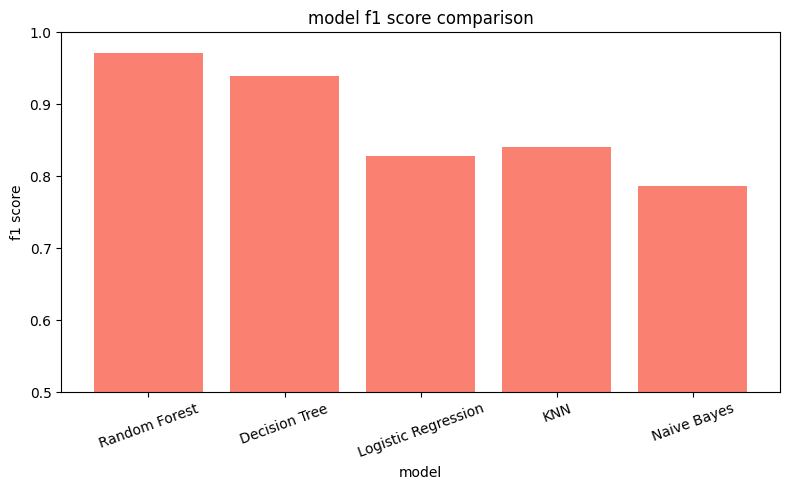

all charts saved!


In [9]:
from sklearn.metrics import f1_score

# chart 7: correlation heatmap
plt.figure(figsize=(10, 8))
top_features = X[['length_url', 'length_hostname', 'nb_dots',
                   'nb_hyphens', 'nb_slash', 'phish_hints',
                   'domain_age', 'web_traffic', 'page_rank',
                   'google_index']]
sns.heatmap(top_features.corr(), annot=True, fmt='.1f', cmap='coolwarm')
plt.title('feature correlation heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

# chart 8: f1 score comparison between models
f1_scores = []

for i in range(len(models)):
    pred = models[i].predict(X_test)
    f1 = f1_score(y_test, pred)
    f1_scores.append(round(f1, 4))

plt.figure(figsize=(8, 5))
plt.bar(names, f1_scores, color='salmon')
plt.title('model f1 score comparison')
plt.ylabel('f1 score')
plt.xlabel('model')
plt.xticks(rotation=20)
plt.ylim([0.5, 1.0])
plt.tight_layout()
plt.savefig('f1_comparison.png')
plt.show()

print("all charts saved!")